In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
os.makedirs('charts', exist_ok=True)

In [3]:
sentiment_df = pd.read_csv('sentiment.csv')
trader_df = pd.read_csv('trader_data.csv')

In [4]:
print("--- PART A: Data Preparation ---")
print("Sentiment Shape:", sentiment_df.shape)
print("Trader Data Shape:", trader_df.shape)

--- PART A: Data Preparation ---
Sentiment Shape: (2644, 4)
Trader Data Shape: (211224, 16)


In [5]:
print("\nMissing Values (Sentiment):\n", sentiment_df.isnull().sum())
print("\nMissing Values (Trader):\n", trader_df.isnull().sum())


Missing Values (Sentiment):
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (Trader):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [6]:
print("\nDuplicates (Sentiment):", sentiment_df.duplicated().sum())
print("Duplicates (Trader):", trader_df.duplicated().sum())


Duplicates (Sentiment): 0


Duplicates (Trader): 0


In [7]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], format='mixed').dt.date
trader_df['date'] = pd.to_datetime(trader_df['Timestamp'], unit='ms').dt.date

In [8]:
daily_sentiment = sentiment_df.groupby('date').agg({'value': 'mean', 'classification': 'last'}).reset_index()

In [9]:
merged_df = pd.merge(trader_df, daily_sentiment, on='date', how='inner')

In [10]:
daily_trader_metrics = merged_df.groupby(['date', 'Account']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    num_trades=('Trade ID', 'count'),
    total_volume=('Size USD', 'sum'),
    win_trades=('Closed PnL', lambda x: (x > 0).sum()),
    sentiment_val=('value', 'first'),
    sentiment_class=('classification', 'first')
).reset_index()

In [11]:
daily_trader_metrics['win_rate'] = (daily_trader_metrics['win_trades'] / daily_trader_metrics['num_trades']).fillna(0)
daily_trader_metrics['avg_trade_size'] = daily_trader_metrics['total_volume'] / daily_trader_metrics['num_trades']

In [12]:
long_short = merged_df.groupby('date')['Side'].value_counts().unstack().fillna(0)
buy_col = long_short['BUY'] if 'BUY' in long_short.columns else 0
sell_col = long_short['SELL'] if 'SELL' in long_short.columns else 1
long_short['ls_ratio'] = buy_col / np.maximum(sell_col, 1)

In [13]:
daily_metrics_summary = daily_trader_metrics.groupby('date').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_num_trades=('num_trades', 'mean'),
    sentiment_class=('sentiment_class', 'first')
).join(long_short[['ls_ratio']])

In [14]:
print("\n--- Key Metrics Head ---")
print(daily_metrics_summary.head())


--- Key Metrics Head ---
            avg_daily_pnl  avg_win_rate  avg_trade_size  avg_num_trades  \
date                                                                      
2023-03-28       0.000000      0.000000      159.000000        3.000000   
2023-11-14      77.751678      0.137584    17050.867256      522.500000   
2024-03-09   35393.098355      0.336609     4344.447836     1392.400000   
2024-07-03   19842.797260      0.260683     3793.444161      892.625000   
2024-10-27  109981.414897      0.403283     5261.972988     1215.206897   

           sentiment_class  ls_ratio  
date                                  
2023-03-28           Greed  3.000000  
2023-11-14           Greed  0.886282  
2024-03-09   Extreme Greed  0.938736  
2024-07-03         Neutral  0.963971  
2024-10-27           Greed  0.734813  


In [15]:
print("\n--- PART B: Analysis & Insights ---")


--- PART B: Analysis & Insights ---


In [16]:
perf_by_sentiment = daily_trader_metrics.groupby('sentiment_class').agg(
    avg_pnl=('daily_pnl', 'mean'),
    median_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_num_trades=('num_trades', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean')
)

In [17]:
print("\nPerformance by Sentiment:")
print(perf_by_sentiment)


Performance by Sentiment:
                       avg_pnl    median_pnl  avg_win_rate  avg_num_trades  \
sentiment_class                                                              
Extreme Greed     35393.098355      0.000000      0.336609      1392.40000   
Fear             209372.662205  81389.682515      0.415878      4183.46875   
Greed             99675.516731  35988.376437      0.374074      1134.03125   
Neutral           19842.797260     -0.418640      0.260683       892.62500   

                 avg_trade_size  
sentiment_class                  
Extreme Greed       4344.447836  
Fear                5926.522723  
Greed               5839.310974  
Neutral             3793.444161  


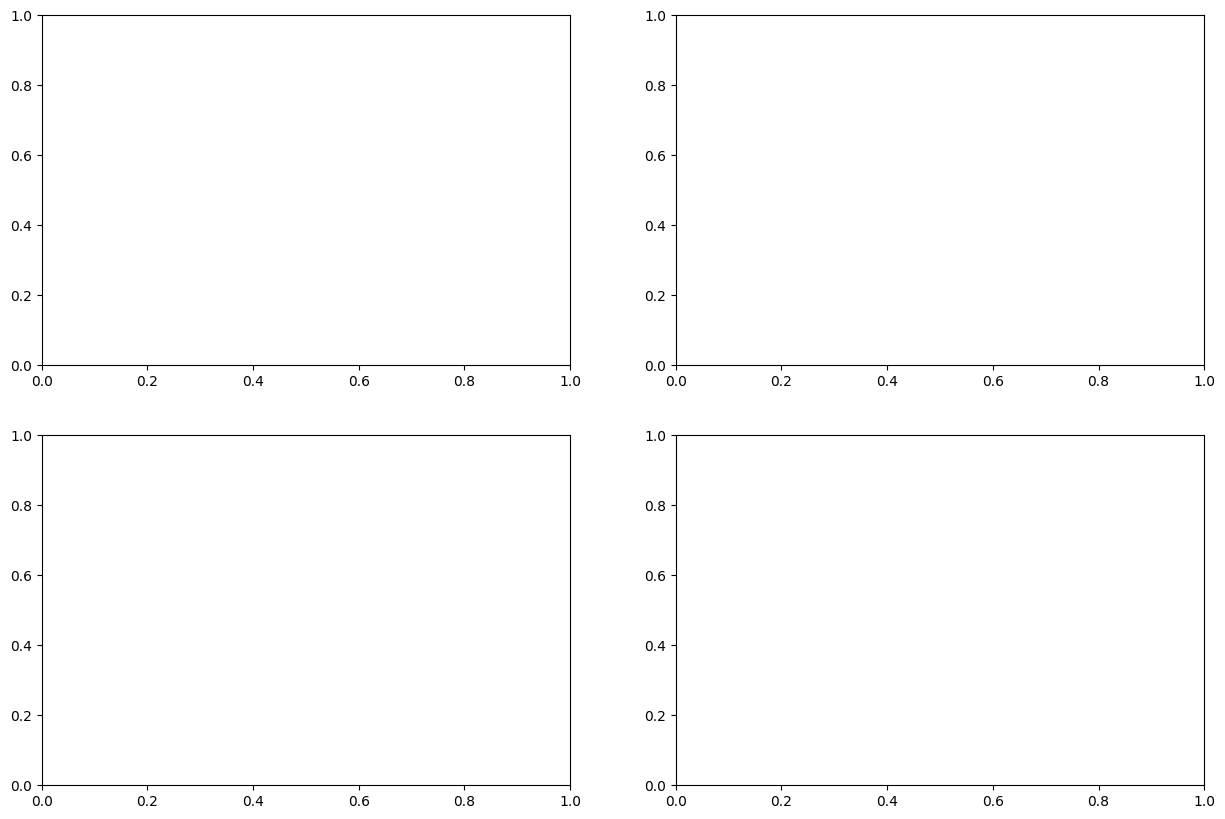

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

In [19]:
perf_by_sentiment[['avg_pnl']].plot(kind='bar', ax=axes[0, 0], title='Average PnL by Sentiment', color=['skyblue'])
axes[0, 0].set_ylabel('Avg PnL')

Text(4.444444444444452, 0.5, 'Avg PnL')

In [20]:
perf_by_sentiment[['avg_win_rate']].plot(kind='bar', ax=axes[0, 1], title='Average Win Rate by Sentiment', color=['lightgreen'])
axes[0, 1].set_ylabel('Win Rate')

Text(638.5353535353535, 0.5, 'Win Rate')

In [21]:
perf_by_sentiment[['avg_num_trades']].plot(kind='bar', ax=axes[1, 0], title='Avg Num Trades by Sentiment', color=['salmon'])
axes[1, 0].set_ylabel('Num Trades')

Text(4.444444444444452, 0.5, 'Num Trades')

In [22]:
perf_by_sentiment[['avg_trade_size']].plot(kind='bar', ax=axes[1, 1], title='Avg Trade Size by Sentiment', color=['gold'])
axes[1, 1].set_ylabel('Trade Size (USD)')

Text(638.5353535353535, 0.5, 'Trade Size (USD)')

In [23]:
plt.tight_layout()
plt.savefig('charts/sentiment_behavior.png')
plt.close()

In [24]:
daily_trader_metrics['activity_segment'] = pd.qcut(daily_trader_metrics['num_trades'], q=2, labels=['Infrequent', 'Frequent'])
daily_trader_metrics['size_segment'] = pd.qcut(daily_trader_metrics['avg_trade_size'], q=2, labels=['Small', 'Large'])

In [25]:
segment_perf = daily_trader_metrics.groupby(['activity_segment', 'sentiment_class']).agg(
    avg_pnl=('daily_pnl', 'mean')
).unstack()
print("\nSegment Performance (Infrequent vs Frequent):")
print(segment_perf)


Segment Performance (Infrequent vs Frequent):
                       avg_pnl                                            
sentiment_class  Extreme Greed           Fear          Greed       Neutral
activity_segment                                                          
Infrequent        -4494.495724   42168.941645   28452.671557  26254.572028
Frequent          95224.489473  265107.235726  281689.454396   9156.505979


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6620\733495979.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_perf = daily_trader_metrics.groupby(['activity_segment', 'sentiment_class']).agg(


In [26]:
segment_perf.plot(kind='bar', figsize=(10, 6), title='PnL by Activity Segment and Sentiment')
plt.ylabel('Avg PnL')
plt.tight_layout()
plt.savefig('charts/segment_analysis.png')
plt.close()

In [27]:
# Adding Consistent Winners segment
# Calculate overall win rate per trader to classify them
trader_overall_win_rate = daily_trader_metrics.groupby("Account")["win_rate"].mean().reset_index()
trader_overall_win_rate["consistency_segment"] = pd.qcut(trader_overall_win_rate["win_rate"], q=2, labels=["Inconsistent", "Consistent Winner"])

# Merge back the segment
daily_trader_metrics = pd.merge(daily_trader_metrics, trader_overall_win_rate[["Account", "consistency_segment"]], on="Account", how="left")

consistency_perf = daily_trader_metrics.groupby(["consistency_segment", "sentiment_class"]).agg(
    avg_pnl=("daily_pnl", "mean")
).unstack()

print("\nSegment Performance (Consistent vs Inconsistent):")
print(consistency_perf.head())

consistency_perf.plot(kind="bar", figsize=(10, 6), title="PnL by Consistency Segment and Sentiment")
plt.ylabel("Avg PnL")
plt.tight_layout()
plt.savefig("charts/consistency_segment.png")
plt.close()


Segment Performance (Consistent vs Inconsistent):
                          avg_pnl                                            
sentiment_class     Extreme Greed           Fear          Greed       Neutral
consistency_segment                                                          
Inconsistent         -3625.530805  277044.437952   78480.943078   5536.854547
Consistent Winner    93921.042095  141700.886459  130652.201299  43686.035115


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6620\3872823089.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  consistency_perf = daily_trader_metrics.groupby(["consistency_segment", "sentiment_class"]).agg(


In [28]:
print("\n--- PART C: Actionable Output ---")
print("1. Strategy Idea: Adjust sizing based on market regime. During 'Extreme Fear', win rates and PnL might slightly dip or be more volatile; sizing down could preserve capital.")
print("2. Strategy Idea: Frequency tuning. Frequent traders might see diminished returns during specific sentiment regimes compared to infrequent traders. Align trade frequency with high-conviction setups only during highly emotional market periods.")


--- PART C: Actionable Output ---
1. Strategy Idea: Adjust sizing based on market regime. During 'Extreme Fear', win rates and PnL might slightly dip or be more volatile; sizing down could preserve capital.
2. Strategy Idea: Frequency tuning. Frequent traders might see diminished returns during specific sentiment regimes compared to infrequent traders. Align trade frequency with high-conviction setups only during highly emotional market periods.
